#Transfer Learning with Med MNIST.

In this assignment you will use transfer learning to train a model of your choice on a sub-dataset from the [MedMNIST datasets](https://medmnist.com/). ![](https://github.com/tonyscan6003/etivities/blob/main/medmnist.JPG?raw=true)

* The [MedMNIST package](https://github.com/MedMNIST/MedMNIST/blob/main/examples/getting_started.ipynb) allows the data to be imported directly as a pytorch dataset.

* You may select any of the datasets using Multi-class/binary classification. The goal is to acheve accuracy levels comparable to the benchmark results shown on the medmnist site. Dataloading for pytorch is setup in the notebook, you wil need to modify the code slightly depending on your dataset of choice.

* Some datasets use black and white images, so you will need to [at least concatenate](https://towardsdatascience.com/transfer-learning-on-greyscale-images-how-to-fine-tune-pretrained-models-on-black-and-white-9a5150755c7a) the input image channels (to 3 channels) for compatibility with the models pre-trained on imageNet.

* Some of the MedMNIST datasets don't contain too much data so Data augmentation may be essentila essential to avoid overfitting. In pytorch data augmentation is performed using the [transforms.v2](https://pytorch.org/vision/main/transforms.html) modules.

* In this notebook: You will need to import a model, and perform training. Tranfer Learning for computer vision is detailed [here](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

* [Tensorboard can be imported](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) to display results.

* Please only include one example of transfer learning in the submitted notebook. Making sure training curves/results are clearly visible. If you have trained additional transfer learning models (i.e. that were less successful) please add this as a table or report at the end of the notebook and/or in your final forum post.




# 1. Install & Import Packages

In [1]:
!pip install medmnist
!pip install torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.9 MB/s eta 0:00:00


In [2]:
import torch
import torchvision
from torch import nn
from torchvision import datasets, models, transforms
from torchvision.transforms import ToTensor, v2, Pad, Grayscale
from torch.utils.data import DataLoader
from tempfile import TemporaryDirectory
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
import time
import os

## 2. Setup & Import Dataset
The [MedMNSIT](https://medmnist.com/) package (imported above) makes available several medical datasets available to access.

You can change the `data_flag` variable (dataset names are all lower case letters) to the dataset of your choice (Take care to note the parameters e.g. number of input channels below that will affect your model)



In [18]:
import medmnist
from medmnist import INFO, Evaluator

# Using the OCTMNIST data set.
# MedMNIST2D 	  Data Modality 	Tasks (# Classes/Labels) 	            Samples 	      Training / Validation / Test
# OCTMNIST      Retinal OCT 	  Multi-Class (4) 	                    109,309 	        97,477 / 10,832     / 1,000

data_flag = 'octmnist'
download = True

BATCH_SIZE = 64

info = INFO[data_flag]
task = info['task']

target_names = info['label']

n_channels = info['n_channels']
n_classes = len(target_names)

print('Type of Machine Learning Task = ',task)
print('Number of Input Data Channels = ',n_channels)
print('Number of Classes = ',n_classes)
print('The batch size for this dataset will be = ',BATCH_SIZE)

DataClass = getattr(medmnist, info['python_class'])

Type of Machine Learning Task =  multi-class
Number of Input Data Channels =  1
Number of Classes =  4
The batch size for this dataset will be =  64


Transforms:
You can update the functions below with appropriate transforms for your particular use case.

* As well as being suitable for data augmention for image classification, the transforms.v2 package of torchvision extends transforms for object detection and segmentation tasks. An illustration of the transforms is shown [here](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html#sphx-glr-auto-examples-transforms-plot-transforms-illustrations-py).
* Normalisation based on ImageNet parameters is included already. This should be used with all models pre-trained on ImageNet  





In [4]:

train_transforms = v2.Compose([
    v2.Resize((224, 224)),
    v2.Grayscale(num_output_channels=3),

    v2.RandomResizedCrop(224, scale=(0.9, 1.0)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(10),
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),

    v2.ToDtype(torch.float32, scale=True),
    ToTensor(),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


test_transforms = v2.Compose([
    v2.Resize((224, 224)),
    v2.Grayscale(num_output_channels=3),

    v2.ToDtype(torch.float32, scale=True),
    ToTensor(),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

Setup your Medmnist dataset.
* The convolution part of pre-trained networks (such as resnet) are compatable with any size input image. However they were trained on 224 x 224 size images, with early layers finding small scale features and deeper layers finding large scale features.
* For this transfer learning application to medical data, the gap between the original ImageNet domain and the medical images is wide. Therefore the size/scale of the input images is less important, however in general we would expect better performance with the larger input images (as they contain more features at different scales).
* You can add the `size=224` parameter to the dataset object calls, to load full size images. Only do this once you are confident in your training methodology (or if the dataset is small), as training with full size images will take longer.


In [5]:
# Download training data from open datasets.
train_dataset = DataClass(split='train', transform=train_transforms, download=download, size=224, mmap_mode='r')
test_dataset = DataClass(split='test', transform=test_transforms, download=download, size=224, mmap_mode='r')
val_dataset = DataClass(split='val', transform=test_transforms, download=download, size=224, mmap_mode='r')


100%|██████████| 3.96G/3.96G [18:00<00:00, 3.67MB/s]


The `Dataset` is passed as an argument to `DataLoader`. This wraps an
iterable over the dataset, and supports automatic batching, sampling,
shuffling and multiprocess data loading.

In [6]:
# Create data loaders.
train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

dataloaders = {
    'train': train_dataloader,
    'val': val_dataloader,
    'test': test_dataloader,
}

image_datasets = {
    'train': train_dataset,
    'val': val_dataset,
    'test': test_dataset
}

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 224, 224])
Shape of y: torch.Size([64, 1]) torch.int64


Plot some example augmented images

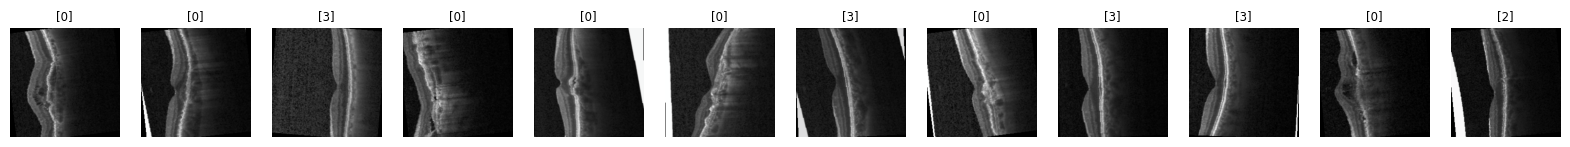

In [7]:
# Output next batch from dataloader
dataiter = iter(train_dataloader)
image_batch, labels_batch = next(dataiter)

# Use matplotlib to plot a sample of images

i=0
n_plots = 12 # number of plots
f, axarr = plt.subplots(1,n_plots,figsize=(20,10))

for image in image_batch[0:n_plots,:,:,:]:
  disp_image =  torch.permute(image,(2,1,0)).numpy() # return image to cpu for display and permute to channels last
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  disp_image = std * disp_image + mean
  disp_image = np.clip(disp_image, 0, 1)
  axarr[i].imshow(disp_image[:,:,:])
  axarr[i].axis("off")
  axarr[i].set_title(labels_batch[i].numpy(),fontsize='small')
  i = i+1


# 3. Define Transfer Learning model
Pytorch has an inbuilt [models package](https://pytorch.org/vision/stable/models.html) that allows loading of popular models with pre-trained weights.

* We want to add an additional classifier stage (to the output of the network). How to setup the [model is detailed here](https://discuss.pytorch.org/t/load-only-a-part-of-the-network-with-pretrained-weights/88397/2).
* This additional classifier may just be a single layer or a cascade of fully connected layers with dropout.
* Note that the number of parameters in the convolutional part of the model will be same no what the input size is set to. However the output feature map size will vary with input image size (small for small image, large for large image). This means the number of parameters in the additional classifier will change depending on input image size.


In [8]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [9]:
# Pre trained model
# Swapping to resnet 18 after forum discussion
from torchvision.models import resnet18, ResNet18_Weights

# Using pretrained weights:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers to keep pretrained features
for param in model.parameters():
    param.requires_grad = False

# Unfreeze Layer4 as suggested by Lateef in discussion
for param in model.layer4.parameters():
    param.requires_grad = True

# Get the number of input features going into the classifier
num_features = model.fc.in_features
num_outputs = 4

# Replace the final fully connected layer
# adding a droupout layer
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 4)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


# 4. Optimisation & Training Loop

Define a training loop that prints the loss from the training and validation set at least every epoch.
* You may choose to make the validation loss calculations more frequent so you can ensure training is progressing satisfactorily (especially with larger datasets).

* You can use tensorboard to visualise the [loss curves](https://pytorch.org/docs/stable/tensorboard.html))

* For multi-class classification classification problem we will use the  [CrossEntropy loss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). In this pytorch function, the input is the un-normalised logit value.

* You may  have to use [torch.squeeze](https://pytorch.org/docs/stable/generated/torch.squeeze.html) to reduce the dimensionality of the label tensor before passing it to the loss function (this due to how the dataset is configured and the loss will only accept 0D or 1D inputs)

['choroidal neovascularization', 'diabetic macular edema', 'drusen', 'normal']


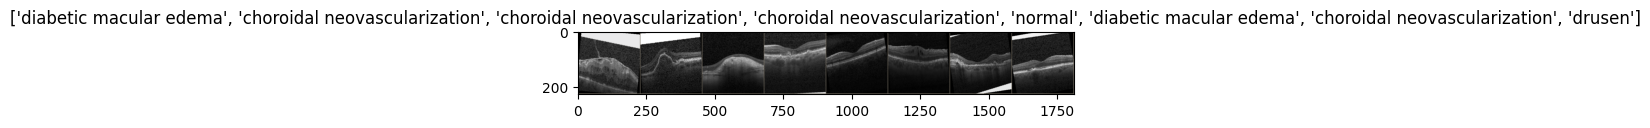

In [42]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = list(train_dataset.info['label'].values())
print(class_names)

# Get a batch of training data (looks off because the batch size is 32)
inputs, classes = next(iter(dataloaders['train']))
inputs = inputs[:8]
labels = classes[:8]

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes[:8]])

In [13]:

# Taken from the PyTorch docs and modified to suit
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for i, (inputs, labels) in enumerate(dataloaders[phase]):
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    labels = labels.squeeze(1)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                        # --- added print ---
                    if i % 200 == 0:   # print every 10 batches
                      print(f'  [{phase}] Batch {i}/{len(dataloaders[phase])}'
                      f'      Loss: {loss.item():.4f}  '
                      f'      Acc: {(preds == labels).float().mean():.4f}')

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [14]:
epochs = 10

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), # Grab trainable params only
    lr=1e-4, # do a smaller learning rate
    weight_decay=1e-4 ) # add weight decay
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # try the CosineAnnealingLR

model = train_model(model, criterion, optimizer, scheduler, num_epochs=epochs)

Epoch 0/9
----------
  [train] Batch 0/1524      Loss: 0.2459        Acc: 0.9062
  [train] Batch 200/1524      Loss: 0.4550        Acc: 0.8438
  [train] Batch 400/1524      Loss: 0.2949        Acc: 0.9062
  [train] Batch 600/1524      Loss: 0.2730        Acc: 0.9219
  [train] Batch 800/1524      Loss: 0.1834        Acc: 0.9688
  [train] Batch 1000/1524      Loss: 0.1328        Acc: 0.9688
  [train] Batch 1200/1524      Loss: 0.1744        Acc: 0.9375
  [train] Batch 1400/1524      Loss: 0.0428        Acc: 0.9844
train Loss: 0.1953 Acc: 0.9340
  [val] Batch 0/170      Loss: 0.2459        Acc: 0.9219
val Loss: 0.1577 Acc: 0.9489

Epoch 1/9
----------
  [train] Batch 0/1524      Loss: 0.2479        Acc: 0.9219
  [train] Batch 200/1524      Loss: 0.1563        Acc: 0.9219
  [train] Batch 400/1524      Loss: 0.1325        Acc: 0.9688
  [train] Batch 600/1524      Loss: 0.0667        Acc: 0.9688
  [train] Batch 800/1524      Loss: 0.0719        Acc: 0.9844
  [train] Batch 1000/1524      Loss

Initialise Tensorboard (use of tensorboard in colab notebooks is [detailed here](https://colab.research.google.com/github/tensorflow/tensorboard/blob/master/docs/tensorboard_in_notebooks.ipynb)). A [Pytorch tutorial](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) shows how to setup the training and validation loop with pytorch.


In [15]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs')

# 5. Evaluate Model
You will need to setup an evaluation loop for the model to assess it's performance on the test dataset.

You may also obtain a classification report after final evaluation of the test dataset with the model using the code below. A confusion matrix can also be obtained and we will plot a few example images.



In [23]:

model.eval()
y_true = []
y_pred = []
probs = []

with torch.no_grad():
    for images, labels in dataloaders['test']:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        softmax_probs = torch.softmax(outputs, dim=1)

        preds = softmax_probs.argmax(dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels[:, 0].cpu().numpy())
        probs.extend(softmax_probs.cpu().numpy())
        print("Unique labels in y_true:", np.unique(y_true))
        print("Unique preds in y_pred:", np.unique(y_pred))
        print("Length of classes:", len(classes))



Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64
Unique labels in y_true: [0 1 2 3]
Unique preds in y_pred: [0 1 2 3]
Length of classes: 64

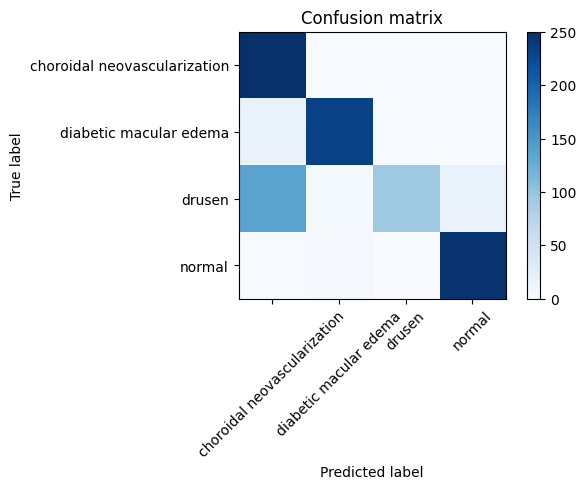

In [44]:
#https://scikit-learn.org/0.16/auto_examples/model_selection/plot_confusion_matrix.html
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_true, y_pred)
def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

plot_confusion_matrix(cm)

In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names))

                              precision    recall  f1-score   support

choroidal neovascularization       0.62      1.00      0.76       250
      diabetic macular edema       0.98      0.93      0.95       250
                      drusen       1.00      0.37      0.54       250
                      normal       0.94      0.99      0.96       250

                    accuracy                           0.82      1000
                   macro avg       0.88      0.82      0.81      1000
                weighted avg       0.88      0.82      0.81      1000



 # Comments about your Approach

# Notes 1
- I think I will use the ChestMNIST data set and the resnet50 model. Just going to get some things setup to start with and see how it goes.
<hr/>

# Notes 2
- Ok re-thinking my use of the ChestMNIST data set and swapped over to the OCTMNIST. I was able to get the data loaded and set up in a way I could use the trainin loop with the same approach that was used in the PyTorch docs.
- I added the criterion, optimizer and scheduler. The criterion I used was the CrossEntropyLoss as suggested in the notebook, for the optimiser I went with AdamW with a learning rate of 0.002 and the scheduler is StepLR. I will do a quick test and see how the accuracy is with a short run of 3 epochs. I also took some inspiration from Melanie after reviewing her work and froze the convolution layers and left the fully connected layer trainable.
- First run below with ResNet50 for 3 Epochs.

| Training Time  | Epochs | Best val Acc   |
|---------|---------------|----------------|
| 24m 38s | 3             | 0.866322       |
<hr/>

# Notes 3
- Some great discussions had with Lateef and Shane on the forums. The main points are that my original choice of ResNet50 might be very slow to train and the trade off between training time and accuracy are probably not worth it. The other point was to unfreeze layer 4 in the network.
- I do need to implement more logging and Shane pointed out a small bug with my 'i' parameter that I now fixe and am happy with seeing the batch updates to let me know how its going.
<hr/>

# Notes 4
- Results of run with ResNet18, unfreezing deeper layers and incerasing Epochs to 10 to begin with.

| Training Time  | Epochs | Best val Acc     |
|-----------|---------------|----------------|
|  58m 25s  | 10               | 0.857736    |


| Criterion      | optimisier  | Scheduler  | Epochs   |
|----------------|-------------|------------|----------|
|CrossEntropyLoss| AdamW       | StepLR     | 10       |

<hr/>

- I stopped being tight and paid for some Google Colab units to speed me along in trainig the models.
- Made some changes to the Criterion, Optimiser, Scheduler and number of Epoch to try reach over the 90% accuracy with ResNet18. Most of these changes are from feedback in the forumnes and reviews of other classmates approaches.
- I reviewed my data augmentations approach as well and added some color jitter as well and saw some nice improvements with this.  


| Criterion      | optimisier  | Scheduler  | Epochs   |
|----------------|-------------|------------|----------|
|CrossEntropyLoss| AdamW       | CosineAnnealingLR     | 10       |

<hr/>

# Summary
- I was aiming to get close to the benchmarch from the medmnist website for my chosen data set. The OctMnist has a AUC/ACC of 0.958/0.763.  
My last run was completed with training time and accuracy as below. <br/>
 - Training complete in 71m 44s
 - Best val Acc: 0.968058